In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("/kaggle/input/datasets/organizations/mlg-ulb/creditcardfraud/creditcard.csv")
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [6]:
df.shape

(284807, 31)

In [7]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [8]:
df.info()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     28

Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64

In [9]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,284807.000000,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,...,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,2.848070e+05,284807.000000,284807.000000
mean,94813.859575,1.168375e-15,3.416908e-16,-1.379537e-15,2.074095e-15,9.604066e-16,1.487313e-15,-5.556467e-16,1.213481e-16,-2.406331e-15,...,1.654067e-16,-3.568593e-16,2.578648e-16,4.473266e-15,5.340915e-16,1.683437e-15,-3.660091e-16,-1.227390e-16,88.349619,0.001727
std,47488.145955,1.958696e+00,1.651309e+00,1.516255e+00,1.415869e+00,1.380247e+00,1.332271e+00,1.237094e+00,1.194353e+00,1.098632e+00,...,7.345240e-01,7.257016e-01,6.244603e-01,6.056471e-01,5.212781e-01,4.822270e-01,4.036325e-01,3.300833e-01,250.120109,0.041527
min,0.000000,-5.640751e+01,-7.271573e+01,-4.832559e+01,-5.683171e+00,-1.137433e+02,-2.616051e+01,-4.355724e+01,-7.321672e+01,-1.343407e+01,...,-3.483038e+01,-1.093314e+01,-4.480774e+01,-2.836627e+00,-1.029540e+01,-2.604551e+00,-2.256568e+01,-1.543008e+01,0.000000,0.000000
25%,54201.500000,-9.203734e-01,-5.985499e-01,-8.903648e-01,-8.486401e-01,-6.915971e-01,-7.682956e-01,-5.540759e-01,-2.086297e-01,-6.430976e-01,...,-2.283949e-01,-5.423504e-01,-1.618463e-01,-3.545861e-01,-3.171451e-01,-3.269839e-01,-7.083953e-02,-5.295979e-02,5.600000,0.000000
50%,84692.000000,1.810880e-02,6.548556e-02,1.798463e-01,-1.984653e-02,-5.433583e-02,-2.741871e-01,4.010308e-02,2.235804e-02,-5.142873e-02,...,-2.945017e-02,6.781943e-03,-1.119293e-02,4.097606e-02,1.659350e-02,-5.213911e-02,1.342146e-03,1.124383e-02,22.000000,0.000000
75%,139320.500000,1.315642e+00,8.037239e-01,1.027196e+00,7.433413e-01,6.119264e-01,3.985649e-01,5.704361e-01,3.273459e-01,5.971390e-01,...,1.863772e-01,5.285536e-01,1.476421e-01,4.395266e-01,3.507156e-01,2.409522e-01,9.104512e-02,7.827995e-02,77.165000,0.000000
max,172792.000000,2.454930e+00,2.205773e+01,9.382558e+00,1.687534e+01,3.480167e+01,7.330163e+01,1.205895e+02,2.000721e+01,1.559499e+01,...,2.720284e+01,1.050309e+01,2.252841e+01,4.584549e+00,7.519589e+00,3.517346e+00,3.161220e+01,3.384781e+01,25691.160000,1.000000


In [10]:
df["Class"].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [11]:
df["Class"].value_counts(normalize=True)

Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64

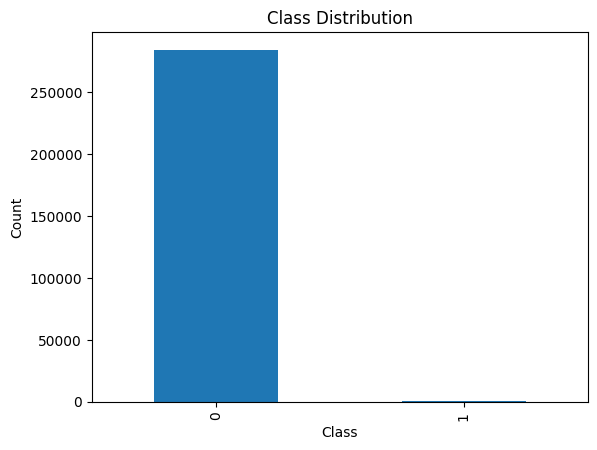

In [12]:
df["Class"].value_counts().plot(kind="bar")
plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.show()

In [13]:
df[["Time", "Amount", "Class"]].describe()

,Time,Amount,Class
count,284807.000000,284807.000000,284807.000000
mean,94813.859575,88.349619,0.001727
std,47488.145955,250.120109,0.041527
min,0.000000,0.000000,0.000000
25%,54201.500000,5.600000,0.000000
50%,84692.000000,22.000000,0.000000
75%,139320.500000,77.165000,0.000000
max,172792.000000,25691.160000,1.000000


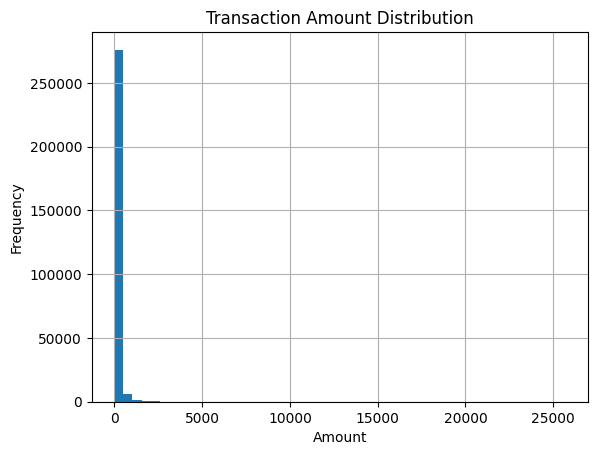

In [14]:
df["Amount"].hist(bins=50)
plt.title("Transaction Amount Distribution")
plt.xlabel("Amount")
plt.ylabel("Frequency")
plt.show()

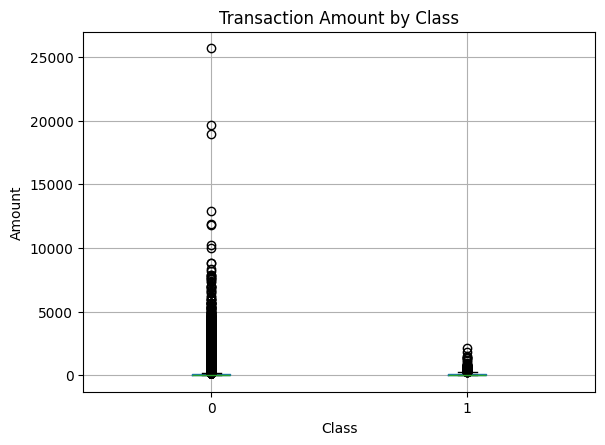

In [15]:
df.boxplot(column="Amount", by="Class")
plt.title("Transaction Amount by Class")
plt.suptitle("")
plt.xlabel("Class")
plt.ylabel("Amount")
plt.show()

- The dataset has no missing values.
- The target variable is highly imbalanced.
- Fraud transactions are a very small minority.
- This means accuracy alone will not be a reliable evaluation metric.

In [16]:
X = df.drop("Class", axis=1)
y = df["Class"]

## Feature matrix and target

The target variable is `Class`, where:
- 0 = non-fraud
- 1 = fraud

All remaining columns are used as input features.

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [18]:
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train class distribution:")
print(y_train.value_counts(normalize=True))
print("y_test class distribution:")
print(y_test.value_counts(normalize=True))

X_train: (227845, 30)
X_test: (56962, 30)
y_train class distribution:
Class
0    0.998271
1    0.001729
Name: proportion, dtype: float64
y_test class distribution:
Class
0    0.99828
1    0.00172
Name: proportion, dtype: float64


## Why stratify?

Because fraud cases are very rare, the train and test sets should preserve approximately the same class ratio as the original dataset.

In [22]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

baseline_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(random_state=42, max_iter=1000))
])

baseline_model.fit(X_train, y_train)

Pipeline(steps=[('scaler', StandardScaler()),
                ('clf', LogisticRegression(max_iter=1000, random_state=42))])

In [23]:
y_pred = baseline_model.predict(X_test)
y_prob = baseline_model.predict_proba(X_test)[:, 1]

In [24]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print("PR-AUC (Average Precision):", average_precision_score(y_test, y_prob))

Confusion Matrix:
[[56851    13]
 [   36    62]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.83      0.63      0.72        98

    accuracy                           1.00     56962
   macro avg       0.91      0.82      0.86     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9605494455801453
PR-AUC (Average Precision): 0.7413820992780461


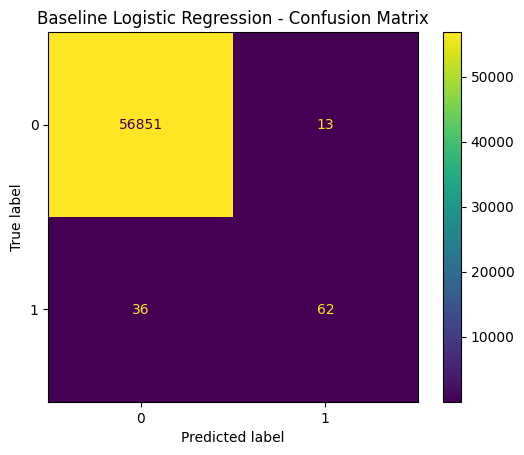

In [25]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.title("Baseline Logistic Regression - Confusion Matrix")
plt.show()

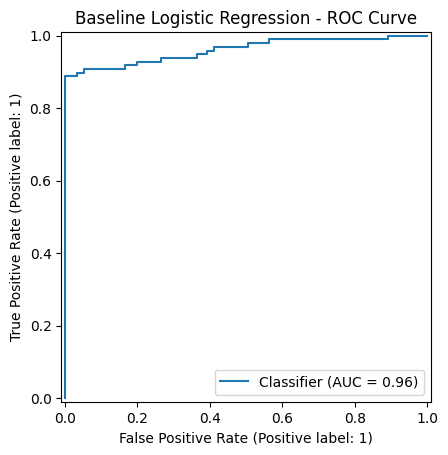

In [27]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_predictions(y_test, y_prob)
plt.title("Baseline Logistic Regression - ROC Curve")
plt.show()

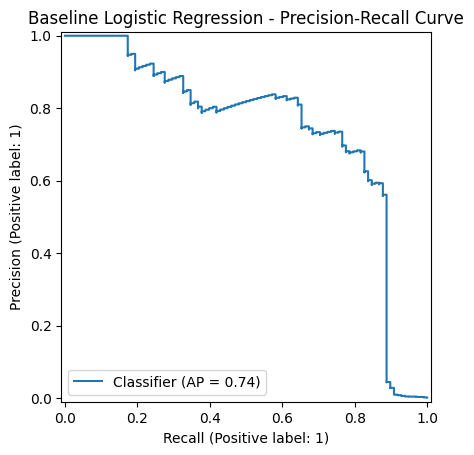

In [28]:
from sklearn.metrics import PrecisionRecallDisplay

PrecisionRecallDisplay.from_predictions(y_test, y_prob)
plt.title("Baseline Logistic Regression - Precision-Recall Curve")
plt.show()

## Baseline model observations

The first baseline model is Logistic Regression with feature scaling.

At this stage, the goal is not to achieve the best possible fraud detection performance, but to establish a simple and interpretable reference point for later comparisons.

Because the dataset is highly imbalanced, metrics such as recall, precision, F1-score, ROC-AUC, and PR-AUC are more informative than accuracy alone.

The confusion matrix and classification metrics will help assess how well the model identifies fraudulent transactions and what trade-off exists between missing fraud cases and generating false alarms.

- confusion matrix: [[56851, 13], [36, 62]]
- fraud precision: about 0.83
- fraud recall: about 0.63
- fraud F1: about 0.72
- ROC-AUC: about 0.961
- PR-AUC: about 0.741

In [30]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)

models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(random_state=42, max_iter=1000))
    ]),
    "Decision Tree": DecisionTreeClassifier(random_state=42, max_depth=5),
    "Random Forest": RandomForestClassifier(
        random_state=42,
        n_estimators=50,
        n_jobs=-1,
        max_depth=10
    )
}

results = []

for name, model in models.items():
    print(f"Training {name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

results_df = pd.DataFrame(results).sort_values(by="PR-AUC", ascending=False)
results_df

Training Logistic Regression...
Training Decision Tree...
Training Random Forest...


,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
2,Random Forest,0.941176,0.816327,0.874317,0.964975,0.864908
0,Logistic Regression,0.826667,0.632653,0.716763,0.960549,0.741382
1,Decision Tree,0.894118,0.775510,0.830601,0.902931,0.740249


In [31]:
balanced_lr = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(
        random_state=42,
        max_iter=1000,
        class_weight="balanced"
    ))
])

balanced_lr.fit(X_train, y_train)
y_pred_bal = balanced_lr.predict(X_test)
y_prob_bal = balanced_lr.predict_proba(X_test)[:, 1]

print(confusion_matrix(y_test, y_pred_bal))
print(classification_report(y_test, y_pred_bal))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_bal))
print("PR-AUC:", average_precision_score(y_test, y_prob_bal))

[[55478  1386]
 [    8    90]]
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962

ROC-AUC: 0.9720834996210077
PR-AUC: 0.7189705771419241


## Model comparison

After establishing Logistic Regression as a baseline, additional models were evaluated to determine whether more flexible classifiers could improve fraud detection performance.

Because the dataset is highly imbalanced, the comparison focuses not only on ROC-AUC, but also on recall, F1-score, and PR-AUC. In fraud detection, missing fraudulent transactions is costly, so recall is particularly important, although it must be balanced against excessive false alarms.

## Model comparison observations

Among the standard models, Random Forest achieved the strongest overall performance. It produced the highest recall, F1-score, ROC-AUC, and PR-AUC, while maintaining very high precision. This suggests that Random Forest is currently the most effective model for fraud detection in this dataset.

Logistic Regression provided a solid and interpretable baseline, but its recall was noticeably lower, meaning that more fraudulent transactions were missed.

Decision Tree improved over Logistic Regression in recall and F1-score, but remained weaker than Random Forest overall.

When class weighting was applied to Logistic Regression, recall increased substantially, indicating that the model became much more sensitive to fraud cases. However, this came at the cost of a dramatic drop in precision, with a large number of false positives. This shows that maximizing recall alone is not sufficient in fraud detection, since an operational system must also avoid excessive false alarms.

In [33]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score
)

rf_models = {
    "RF_default": RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        n_jobs=-1
    ),
    
    "RF_balanced": RandomForestClassifier(
        random_state=42,
        n_estimators=100,
        n_jobs=-1,
        class_weight="balanced"
    ),
    
    "RF_deeper_controlled": RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        n_jobs=-1,
        max_depth=10
    ),
    
    "RF_balanced_depth10": RandomForestClassifier(
        random_state=42,
        n_estimators=200,
        n_jobs=-1,
        max_depth=10,
        class_weight="balanced"
    )
}
rf_results = []

for name, model in rf_models.items():
    print(f"Training {name}...")
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    rf_results.append({
        "Model": name,
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob),
        "PR-AUC": average_precision_score(y_test, y_prob)
    })

rf_results_df = pd.DataFrame(rf_results).sort_values(by="PR-AUC", ascending=False)
rf_results_df

Training RF_default...
Training RF_balanced...
Training RF_deeper_controlled...
Training RF_balanced_depth10...


,Model,Precision,Recall,F1,ROC-AUC,PR-AUC
0,RF_default,0.941176,0.816327,0.874317,0.963027,0.873391
2,RF_deeper_controlled,0.941176,0.816327,0.874317,0.975891,0.864180
1,RF_balanced,0.960526,0.744898,0.839080,0.952908,0.854200
3,RF_balanced_depth10,0.808081,0.816327,0.812183,0.980396,0.820416


In [34]:
best_rf = rf_models["RF_default"]
y_pred_best = best_rf.predict(X_test)
y_prob_best = best_rf.predict_proba(X_test)[:, 1]

from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred_best))
print(classification_report(y_test, y_pred_best))
print("ROC-AUC:", roc_auc_score(y_test, y_prob_best))
print("PR-AUC:", average_precision_score(y_test, y_prob_best))

[[56859     5]
 [   18    80]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.94      0.82      0.87        98

    accuracy                           1.00     56962
   macro avg       0.97      0.91      0.94     56962
weighted avg       1.00      1.00      1.00     56962

ROC-AUC: 0.9630272515590367
PR-AUC: 0.8733910547021404


## Random Forest tuning results

Several Random Forest configurations were tested to determine whether class weighting or depth control could improve fraud detection performance.

Among all tested variants, the default Random Forest achieved the strongest overall performance. It produced the highest PR-AUC and F1-score while maintaining both high precision and high recall. In particular, it correctly detected 80 out of 98 fraudulent transactions while producing only 5 false positives.

Adding class weighting did not improve the model. Although one balanced configuration increased precision slightly, it reduced recall and worsened the overall trade-off. Another balanced depth-controlled model achieved a higher ROC-AUC, but its PR-AUC and F1-score were lower, making it less suitable for this highly imbalanced fraud detection task.

These results suggest that the default Random Forest provides the best balance between fraud capture and false alarm rate among the tested models.

In [35]:
y_prob_best = best_rf.predict_proba(X_test)[:, 1]

In [36]:
import numpy as np
from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix

thresholds = [0.1, 0.2, 0.3, 0.4, 0.5]

threshold_results = []

for thresh in thresholds:
    y_pred_thresh = (y_prob_best >= thresh).astype(int)
    
    threshold_results.append({
        "Threshold": thresh,
        "Precision": precision_score(y_test, y_pred_thresh),
        "Recall": recall_score(y_test, y_pred_thresh),
        "F1": f1_score(y_test, y_pred_thresh),
        "FP": confusion_matrix(y_test, y_pred_thresh)[0, 1],
        "FN": confusion_matrix(y_test, y_pred_thresh)[1, 0],
        "TP": confusion_matrix(y_test, y_pred_thresh)[1, 1]
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,Threshold,Precision,Recall,F1,FP,FN,TP
0,0.1,0.719008,0.887755,0.794521,34,11,87
1,0.2,0.796296,0.877551,0.834951,22,12,86
2,0.3,0.860000,0.877551,0.868687,14,12,86
3,0.4,0.933333,0.857143,0.893617,6,14,84
4,0.5,0.941176,0.816327,0.874317,5,18,80


## Threshold tuning analysis

The default classification threshold of 0.5 does not necessarily provide the best trade-off for fraud detection. Since fraud detection is a highly imbalanced and cost-sensitive problem, threshold tuning was performed to evaluate how changing the decision threshold affects precision, recall, and false alarm rate.

The results show that lowering the threshold increases recall, meaning that more fraudulent transactions are detected, but this usually comes at the cost of lower precision and more false positives.

Among the tested thresholds, 0.4 provided the best overall balance. Compared with the default threshold of 0.5, it reduced the number of missed fraud cases while increasing false positives only slightly. It also achieved the highest F1-score, suggesting a more effective balance between fraud capture and false alarms.

A threshold of 0.3 also performed strongly and may be preferred in settings where capturing more fraud is more important than minimizing false alerts.

In [37]:
feature_importances = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": best_rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

feature_importances.head(15)

,Feature,Importance
17,V17,0.170325
14,V14,0.136363
12,V12,0.133326
10,V10,0.074073
16,V16,0.071792
11,V11,0.045277
9,V9,0.031127
4,V4,0.030496
18,V18,0.028156
7,V7,0.024627


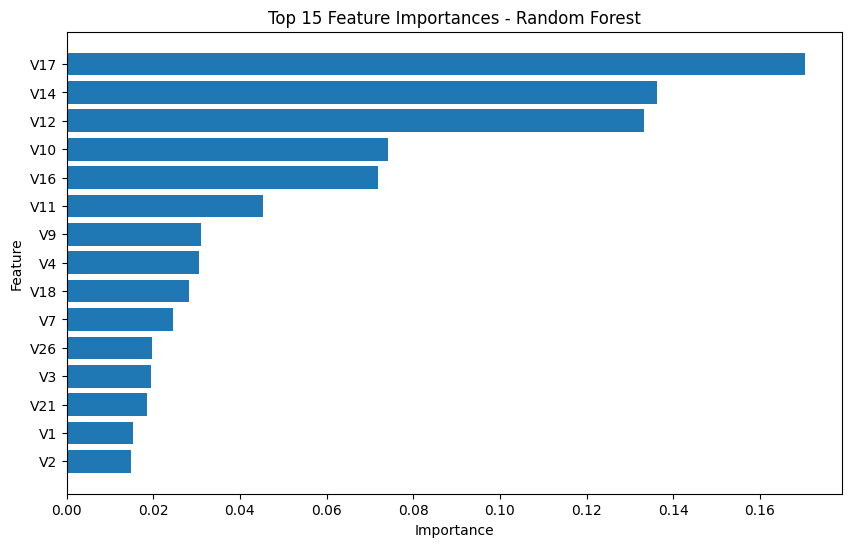

In [38]:
top_n = 15
top_features = feature_importances.head(top_n)

plt.figure(figsize=(10, 6))
plt.barh(top_features["Feature"], top_features["Importance"])
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

## Feature importance analysis

The Random Forest model relies most heavily on a small number of features, especially **V17**, **V14**, and **V12**. This suggests that the fraud detection signal is concentrated in a limited subset of variables rather than being spread equally across all features.

However, these variables are anonymized transformed features, so their exact real-world meaning is unknown. For this reason, the analysis shows which variables are important for prediction, but not why they are important in a business sense.

It is also notable that **Time** and **Amount** are not among the top-ranked features, which suggests that the transformed variables contain much stronger information for distinguishing fraudulent and non-fraudulent transactions.

## Final conclusion

This project investigated credit card fraud detection using a highly imbalanced transaction dataset. The analysis began with exploratory data analysis, which showed that fraudulent transactions represent only a very small fraction of the data, making accuracy alone an unreliable evaluation metric.

A Logistic Regression model was first used as a baseline. While it achieved strong overall discrimination, its recall on the fraud class remained limited. Several alternative models were then tested, including Decision Tree and Random Forest. Among them, Random Forest provided the strongest overall performance, achieving the best balance between fraud detection and false alarm control.

Additional experiments showed that simply forcing stronger minority-class emphasis, such as through class weighting, can substantially increase recall but may also lead to an unacceptable number of false positives. This highlighted the importance of evaluating fraud detection models using precision, recall, F1-score, ROC-AUC, and especially PR-AUC.

Threshold tuning further improved the practical usefulness of the selected Random Forest model. In particular, lowering the classification threshold from 0.5 to 0.4 produced a better balance between fraud capture and false alarms, reducing missed fraud cases while increasing false positives only slightly.

Finally, feature importance analysis showed that the model relied most strongly on a relatively small subset of anonymized transformed variables, especially V17, V14, and V12. This suggests that the predictive signal is concentrated in a limited number of features, although their exact real-world meaning cannot be interpreted directly because of anonymization.

Overall, the project demonstrates that fraud detection on imbalanced tabular data requires more than simply choosing a classifier. Model selection, threshold tuning, and careful metric interpretation all play an essential role in building a practically useful system.